In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:

print("=" * 60)
print("PART A: MANUAL CALCULATIONS")
print("=" * 60)

PART A: MANUAL CALCULATIONS


In [4]:
# 1. Create simple dataset
print("\n1. Sample Dataset:")
print("Features: [Age, Income]")
print("Target: Buy\n")

data = [
    [0, 0, 0],
    [0, 0, 0],
    [1, 0, 0],
    [2, 0, 0],
    [2, 1, 1],
    [2, 1, 1],
    [1, 1, 1],
    [0, 1, 0],
    [2, 0, 1],
    [0, 1, 1]
]

df = pd.DataFrame(data, columns=['Age', 'Income', 'Buy'])
print(df.to_string(index=False))


1. Sample Dataset:
Features: [Age, Income]
Target: Buy

 Age  Income  Buy
   0       0    0
   0       0    0
   1       0    0
   2       0    0
   2       1    1
   2       1    1
   1       1    1
   0       1    0
   2       0    1
   0       1    1


In [5]:
# 2. Gini Impurity
print("\n2. Gini Impurity Calculation:")
labels = df['Buy'].values

n_total = len(labels)
n_yes = sum(labels)
n_no = n_total - n_yes

p_yes = n_yes / n_total
p_no = n_no / n_total

gini = 1 - (p_yes**2 + p_no**2)

print(f"Total: {n_total}, Yes: {n_yes}, No: {n_no}")
print(f"P(Yes)={p_yes:.2f}, P(No)={p_no:.2f}")
print(f"Gini = {gini:.4f}")


2. Gini Impurity Calculation:
Total: 10, Yes: 5, No: 5
P(Yes)=0.50, P(No)=0.50
Gini = 0.5000


In [6]:
# 3. Entropy
print("\n3. Entropy Calculation:")
entropy = 0

if p_yes > 0:
    entropy -= p_yes * np.log2(p_yes)

if p_no > 0:
    entropy -= p_no * np.log2(p_no)

print(f"Entropy = {entropy:.4f}")


3. Entropy Calculation:
Entropy = 1.0000


In [8]:
# 4. Example Split: Age <= 1
print("\n4. Example Split: Age <= 1")

left = df[df['Age'] <= 1]['Buy'].values
right = df[df['Age'] > 1]['Buy'].values

def simple_gini(y):
    if len(y) == 0:
        return 0
    p1 = sum(y) / len(y)
    p0 = 1 - p1
    return 1 - (p1**2 + p0**2)

gini_left = simple_gini(left)
gini_right = simple_gini(right)

# Information gain

weighted_gini = (len(left)/n_total)*gini_left + (len(right)/n_total)*gini_right
information_gain = gini - weighted_gini

print(f"Left branch: {list(left)}")
print(f"Right branch: {list(right)}")
print(f"Gini(left) = {gini_left:.4f}")
print(f"Gini(right) = {gini_right:.4f}")
print(f"Weighted Gini = {weighted_gini:.4f}")
print(f"Information Gain = {information_gain:.4f}")


4. Example Split: Age <= 1
Left branch: [0, 0, 0, 1, 0, 1]
Right branch: [0, 1, 1, 1]
Gini(left) = 0.4444
Gini(right) = 0.3750
Weighted Gini = 0.4167
Information Gain = 0.0833


In [9]:
# =====================================================
# PART B: IRIS DATASET IMPLEMENTATION
# =====================================================

print("\n" + "=" * 60)
print("PART B: IRIS DATASET ANALYSIS")
print("=" * 60)


PART B: IRIS DATASET ANALYSIS


In [10]:
# 1. Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Use only first 2 features for simple visualization
X_simple = X[:, :2]
feature_names = iris.feature_names[:2]
target_names = iris.target_names

print(f"\nSamples: {len(X)}")
print(f"Features Used: {feature_names}")
print(f"Classes: {target_names}")



Samples: 150
Features Used: ['sepal length (cm)', 'sepal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [11]:
# 2. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.3, random_state=42
)

print(f"\nTraining Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")



Training Samples: 105
Testing Samples: 45


In [12]:
# 3. Train with Gini
print("\n3. Train Decision Trees")
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=3)
dt_gini.fit(X_train, y_train)
# Train with Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3)
dt_entropy.fit(X_train, y_train)



3. Train Decision Trees


DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [13]:
# 4. Evaluate
y_pred_gini = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

acc_gini = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"\nGini Accuracy: {acc_gini:.3f}")
print(f"Entropy Accuracy: {acc_entropy:.3f}")


Gini Accuracy: 0.756
Entropy Accuracy: 0.667



Visualizing Trees...


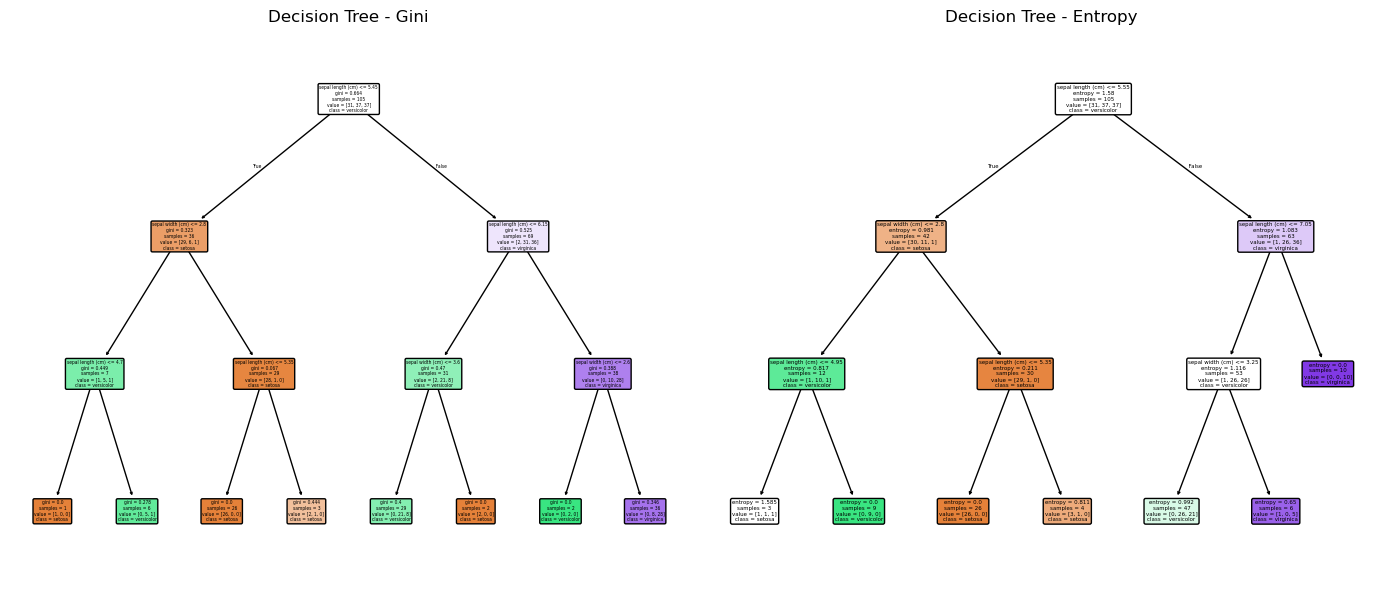

In [14]:
# 5. Visualize Trees
print("\nVisualizing Trees...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_tree(
    dt_gini,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    ax=ax1
)
ax1.set_title("Decision Tree - Gini")

plot_tree(
    dt_entropy,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    ax=ax2
)
ax2.set_title("Decision Tree - Entropy")

plt.tight_layout()
plt.savefig("simple_trees.png", dpi=100, bbox_inches='tight')
plt.show()


In [15]:
# 6. Feature importance
print("\n6. Feature Importance")
print(f"   Gini Importance:")
for name, imp in zip(feature_names, dt_gini.feature_importances_):
    print(f"     {name}: {imp:.3f}")
print(f"\n   Entropy Importance:")
for name, imp in zip(feature_names, dt_entropy.feature_importances_):
    print(f"     {name}: {imp:.3f}")



6. Feature Importance
   Gini Importance:
     sepal length (cm): 0.723
     sepal width (cm): 0.277

   Entropy Importance:
     sepal length (cm): 0.686
     sepal width (cm): 0.314


In [17]:
# 7. Simple pruning test
print("\n7. Test Pruning (max_depth)")
depths = [1, 2, 3, 4, 5]
print("   Depth | Gini Acc | Entropy Acc")
print("   " + "-" * 30)
for depth in depths:
    # Gini
    dt_g = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt_g.fit(X_train, y_train)
    acc_g = accuracy_score(y_test, dt_g.predict(X_test))
    
    # Entropy
    dt_e = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt_e.fit(X_train, y_train)
    acc_e = accuracy_score(y_test, dt_e.predict(X_test))
    print(f"   {depth:5d} | {acc_g:8.3f} | {acc_e:10.3f}")



7. Test Pruning (max_depth)
   Depth | Gini Acc | Entropy Acc
   ------------------------------
       1 |    0.644 |      0.667
       2 |    0.756 |      0.711
       3 |    0.756 |      0.667
       4 |    0.756 |      0.800
       5 |    0.756 |      0.756
